# Implementation of Lambert Liu

### Imports and config dicts

In [ ]:
import numpy as np 
import polars as pl 
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from numba import njit  
import math 
from collections import namedtuple

ModuleNotFoundError: No module named 'polars'

In [ ]:
config_dict = {
    # Binning configs
    'fine_bin_mins' : 5,
    'coarse_bin_mins' : 60,

    # Train, burn in, test validation split config
    'train_days' : 7,
    'burn_in_days' : 7,
    'validation_days' : 7,
    'test_days' : 7,
    
    # Min Params
    'mean_min' : 1e-8,
    'var_min' : 1e-8,
    'min_mean_var_diff' : 1e-8,
    
    # Smoothing Strength and w
    'smoothing_strength' : 0.2, 
    'w' : 0.1,
    
    # setting the seed (used in k means) and clustering method
    'seed' : 110,
    'clustering_method' : 'k_means'}

### Loading and saving data 

In [ ]:
data_path = '/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate'
input_data = 'train_df'
df = pl.scan_parquet(f'{data_path}/input/{input_data}.parquet')


# Creating functions for storing and reading data
def store_data(data, filename, data_path=data_path):
    if isinstance(data, pl.LazyFrame):
        data.sink_parquet(f'{data_path}/output/{filename}.parquet')
    elif isinstance(data, np.ndarray):
        np.save(f'{data_path}/output/{filename}.npy', data)
    elif isinstance(data, pl.DataFrame):
        data.write_parquet(f'{data_path}/output/{filename}.parquet')
    else:
        raise TypeError('Function doesnt support this data type')
    

def load_data(filename, data_type, data_path=data_path):
    ''' 
    Arguments:
        filename: 
            the saved file name
        data_type: ['lazy', 'np', 'df']
            the type of data we want to load in
    '''
    if data_type == 'lazy':
        data = pl.scan_parquet(f'{data_path}/output/{filename}.parquet')
    elif data_type == 'np':
        data = np.load(f'{data_path}/output/{filename}.npy')
    elif data_type == 'df':
        data = pl.read_parquet(f'{data_path}/output/{filename}.parquet')
    else:
        raise TypeError('Function doesnt support this data type')
    return data

### Getting helper dictionaries

In [ ]:
# Helper functions outputing dicitonaries
def get_bin_metrics(config_dict=config_dict):
    ''' 
    Returns a dictionary containing all information needed about bin length these numbers are needed throughout the pipeline
    '''
    # Check that bin length divides number of days
    assert 24 * 60 % config_dict['fine_bin_mins'] == 0
    assert 24 * 60 % config_dict['coarse_bin_mins'] == 0
    assert config_dict['coarse_bin_mins'] % config_dict['fine_bin_mins'] == 0

    output_dict = {'fine_bins_per_day' : 24 * 60 // config_dict['fine_bin_mins']}
    output_dict['fine_bins_per_week'] = output_dict['fine_bins_per_day'] * 7
    output_dict['fine_bins_per_coarse_bin'] = config_dict['coarse_bin_mins'] // config_dict['fine_bin_mins']
    output_dict['coarse_bins_per_week'] = output_dict['fine_bins_per_week'] // output_dict['fine_bins_per_coarse_bin']
    output_dict['fine_bin_seconds'] = config_dict['fine_bin_mins'] * 60 

    return output_dict

def get_train_test_split(config_dict=config_dict):
    ''' 
    Calculates the fine bin index of the train test and validation period start and end
    Returns a dictionary with all this information in
    '''

    fine_bins_per_day = 24 * 60 // config_dict['fine_bin_mins']

    train_bins = fine_bins_per_day * config_dict['train_days']
    burn_in_bins = fine_bins_per_day * config_dict['burn_in_days']
    validation_bins = fine_bins_per_day * config_dict['validation_days']
    test_bins = fine_bins_per_day * config_dict['test_days']

    # Constructing a dict for the output
    output_dict = {'train_start' : 0,
                   'train_end' : train_bins}
    
    output_dict['burn_in_start'] = output_dict['train_end']
    output_dict['burn_in_end'] = output_dict['burn_in_start'] + burn_in_bins

    output_dict['validation_start'] = output_dict['burn_in_end']
    output_dict['validation_end'] = output_dict['validation_start'] + validation_bins

    output_dict['test_start'] = output_dict['validation_end']
    output_dict['test_end'] = output_dict['test_start'] + test_bins
    
    return output_dict
    
# Adding the fine_bins_per_coarse_bin to the train_test_split_dict
def add_training_denom(bin_metric_dict, config_dict=config_dict):
    ''' 
    Finds how many fine bins are used for the estimate of the iniatial parameter.
    This is the denominator on the mean estimate as it is counts/bins and is similarly used in the variance estimate.

    This fucntion assumes train days is a multiple of 7 to work

    Returns:
        An updated bin metric dict with a new column train denom
    '''
    assert config_dict['train_days'] % 7 == 0
    bin_metric_dict['train_denom'] = bin_metric_dict['fine_bins_per_coarse_bin'] * (config_dict['train_days'] // 7)
    return bin_metric_dict

In [ ]:
# Uses the above functions to get 2 dictionaries 
# train_test_dict with the fine bins index upon which we make the train test split
# bin metric dict which calculates metric such as fine bins per day and fine bins used in the training estimate
train_test_dict = get_train_test_split()
bin_metric_dict = get_bin_metrics()
bin_metric_dict = add_training_denom(bin_metric_dict)

### Preprocessing data

This involves:

    - Turning the source_user@domain column into a user_id to make it more lightweight
    - Making the fine bin column and getting counts in each fine bin
    - Making the course bin column
    - Getting the fine bin within coarse bin position

In [ ]:
# Creating a fine bin and identifying users with some counts in the bin

def create_counts_data(df):
    ''' 
    Gets the counts per fine bin x source user from the data
    '''
    df = df.with_columns(time = pl.col('time').dt.total_seconds())
    df = df.with_columns(fine_bin_id = pl.col('time') // bin_metric_dict['fine_bin_seconds'])
    user_x_fine_bin_cnts = df.group_by(['source_user@domain', 'fine_bin_id']).agg(pl.len().alias('count')).collect()
    return user_x_fine_bin_cnts

def create_user_to_id_mapping(users_df, mapping_file_name):
        ''' 
        Creates a table containing the 
        '''
        # Creating a user lookup table and storing it
        user_mapping = users_df.select('source_user@domain').unique().sort(by='source_user@domain').with_row_index('user_id')
        store_data(user_mapping, mapping_file_name)
        
        # Joining on the lookup table and dropping columns
        users_df = users_df.join(user_mapping, on='source_user@domain', how='inner')
        users_df = users_df.select(['user_id', 'fine_bin_id', 'count']).sort(['user_id', 'fine_bin_id'])

        return users_df, user_mapping

def create_coarse_bins(users_df):
        ''' 
        takes a DF and creates two new columns:
            coarse_bin_id
            fine_bin_within_coarse_pos
        '''
        # Creating columns needed fr
        users_df = users_df.with_columns(fine_bin_pos_in_week = pl.col('fine_bin_id') % bin_metric_dict['fine_bins_per_week'])
        users_df = users_df.with_columns(
            coarse_bin_id = pl.col('fine_bin_pos_in_week') // bin_metric_dict['fine_bins_per_coarse_bin'],
            fine_bin_within_coarse_pos = pl.col('fine_bin_pos_in_week') % bin_metric_dict['fine_bins_per_coarse_bin'])

        return users_df

In [ ]:
# Doing initial manipulations on the data including replacing source_user@domain with user_id and constructing course and fine bins
df_counts = create_counts_data(df)
df_counts, user_mapping = create_user_to_id_mapping(df_counts, mapping_file_name='source_users_to_id_mapping')
df_counts = create_coarse_bins(df_counts)

### Getting inital parameter estimates and interpolation weights

In [ ]:
def get_training_sums(df_counts, train_test_dict=train_test_dict):
    ''' 
    Creates the training data and the sum of counts and sum of counts squared columns

    This data is used to get the initial parameter estimates
    '''

    train_df = df_counts.filter((pl.col('fine_bin_id') >= train_test_dict['train_start'])
                                    & (pl.col('fine_bin_id') < train_test_dict['train_end']))

    train_df = train_df.with_columns(count_2 = pl.col('count') ** 2)
    train_df = train_df.group_by(['user_id', 'coarse_bin_id']).agg(pl.sum('count').alias('sum_cnt'), pl.sum('count_2').alias('sum_cnt_2'))
    
    return train_df 


def create_init_grids(df_counts, n_users, n_coarse_bins, bin_metric_dict=bin_metric_dict):
    ''' 
    Creates the u and v init grids from the training data
    '''
    # Getting the sum of counts and sum of counts squared needed for mean and variance calculations
    train_df = get_training_sums(df_counts)
    
    # Init a grid of parmeters to use
    u_init = np.zeros((n_users, n_coarse_bins))
    v_init = np.zeros((n_users, n_coarse_bins))

    # Extrating the entries to assign and assigning them to the df
    entries_to_assign = train_df.select(['user_id', 'coarse_bin_id']).to_numpy()

    u_init[entries_to_assign[:,0], entries_to_assign[:,1]] = train_df['sum_cnt'].to_numpy() / bin_metric_dict['train_denom']
    v_init[entries_to_assign[:,0], entries_to_assign[:,1]] = (train_df['sum_cnt_2'].to_numpy() - 
                                                            ((train_df['sum_cnt'] **2) / bin_metric_dict['train_denom']))/(bin_metric_dict['train_denom'] - 1)

    # Capping the min values of u_init and v_init
    u_init = np.maximum(u_init, config_dict['mean_min'])
    v_init = np.maximum(v_init, config_dict['var_min'])

    return u_init, v_init

NameError: name 'train_test_dict' is not defined

In [ ]:
# Creatung the inital grids and saving the outputs
u_init, v_init = create_init_grids(df_counts, n_users = user_mapping.shape[0], n_coarse_bins = bin_metric_dict['coarse_bins_per_week'])

store_data(u_init, 'u_init')
store_data(v_init, 'v_init')

In [ ]:
# Normalising U init for clustering
u_init = u_init / u_init.sum(axis=1, keepdims=True)

### Getting raw and clustered model

In [ ]:
### Creating clusters and then initialising a cluster model
#! NOTE right now this clustering doesnt work very well assigning most users to cluster 0 and very few users to the other clusters. 
#! We will work on clustering down the line and check if this will be resolved when we filter out the 0 users

#! NOTE also we should probably cluster the data based on the parameters for the full training data not just for the first week of train

def get_k_means_assignments(k, random_state, vec_to_cluster=u_init):
    '''
    Performs k means clustering on a numpy array and returns a vector of cluster assignments
    '''

    k_means_cluster = KMeans(n_clusters=k, random_state=random_state)
    clusters = k_means_cluster.fit_predict(vec_to_cluster).astype(np.int64)

    return clusters

def get_cluster_assignments(clustering_param, config_dict=config_dict, vec_to_cluster=u_init):
    ''' 
    Generic clustering runner that can be scaled to include multiple algorithms
    '''
    if config_dict['clustering_method'] == 'k_means':
        return get_k_means_assignments(k=clustering_param, random_state=config_dict['seed'], vec_to_cluster=vec_to_cluster)
    else:
        raise ValueError('Clustering method not Reckognised')
    
def get_clustering_means(cluster_groups, u_init=u_init, v_init=v_init):
    ''' 
    Calculates mean u and v values for each cluster group and each time bin
    Used within the get clustering model function
    Args:
        cluster_groups a n_users length vector of cluster assignments
        u_init : the calculated vector of parameter means
        v_init : the calculated vector of initial parameter variances
    '''

    n_users, n_coarse_bins = u_init.shape 
    n_clusters = cluster_groups.max() + 1
    print(f'Number of clusters identified : {n_clusters}')

    # Init mean vectors
    cluster_mean_u = np.zeros((n_clusters, n_coarse_bins), dtype='float64')
    cluster_mean_v = np.zeros((n_clusters, n_coarse_bins), dtype='float64')
    users_per_cluster = np.zeros(n_clusters, dtype='float64')

    # Summing u and v contributions in each cluster
    # Extract the cluster assignment for each user and then add their parameters to each bin
    for user_id in range(n_users):
        cluster_assignment = int(cluster_groups[user_id])
        cluster_mean_u[cluster_assignment, :] += u_init[user_id, :]
        cluster_mean_v[cluster_assignment, :] += v_init[user_id, :]
        users_per_cluster[cluster_assignment] += 1

    # Dividing through to get the averages in each cluster
    for cluster_assignment in range(n_clusters):
        if users_per_cluster[cluster_assignment] > 0:
            cluster_mean_u[cluster_assignment, :] /= users_per_cluster[cluster_assignment]
            cluster_mean_v[cluster_assignment, :] /= users_per_cluster[cluster_assignment]

    return cluster_mean_u, cluster_mean_v

def make_cluster_model(cluster_param, smoothing_strength, config_dict, u_init=u_init, v_init=v_init):
    ''' 
    Creates the clustering model dictionary 
    '''
    cluster_assignments = get_cluster_assignments(clustering_param=cluster_param)
    cluster_mean_u, cluster_mean_v = get_clustering_means(u_init=u_init, v_init=v_init, cluster_groups=cluster_assignments)

    output = {'name' : f"{config_dict['clustering_method']}",
              'cluster_param' : cluster_param,
              'cluster_mean_u' : cluster_mean_u,
              'cluster_mean_v' : cluster_mean_v,
              'smoothing_strength' : smoothing_strength,
              'cluster_assignments' : cluster_assignments}

    return output 
    
# Getting the clustering model
clustering_model = make_cluster_model(cluster_param=4, smoothing_strength=config_dict['smoothing_strength'], config_dict=config_dict)

Number of clusters identified : 4


In [ ]:
cluster_mean_bins = clustering_model['cluster_mean_u']

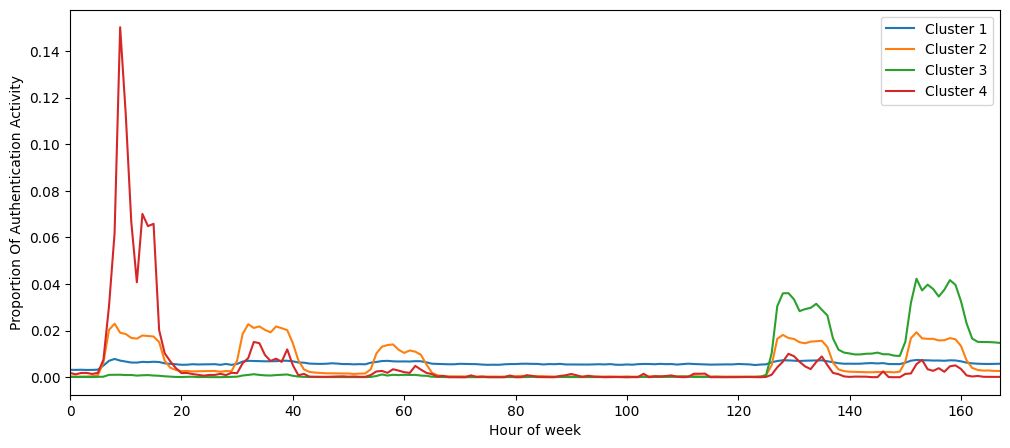

In [21]:
hours = np.arange(cluster_mean_bins.shape[1])

# Iterate over the cluster and plot
plt.figure(figsize=(12,5))
for cluster_number in range(cluster_mean_bins.shape[0]):
    plt.plot(hours, cluster_mean_bins[cluster_number], label=f'Cluster {cluster_number + 1}')

plt.xlabel('Hour of week')
plt.ylabel('Proportion Of Authentication Activity')
plt.xlim((0,167))
plt.legend(loc='upper right')
plt.savefig('cluster_means_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [16]:
# Getting how many human and machine users are in each cluster
cluster_assignments = clustering_model['cluster_assignments']
cluster_users = pl.DataFrame({'user_id': np.arange(len(cluster_assignments)), 'cluster': cluster_assignments})

cluster_users = user_mapping.join(cluster_users, on='user_id', how='inner')
cluster_users = cluster_users.with_columns(pl.when(pl.col('source_user@domain').str.contains(r'\$@')
                                                   ).then(pl.lit('machine')).otherwise(pl.lit('human')).alias('source_user_type'))

cluster_users = cluster_users.group_by(['cluster', 'source_user_type']).len().sort(['cluster', 'source_user_type'])

In [19]:
cluster_users.with_columns(cluster=(pl.col('cluster')+1))

cluster,source_user_type,len
i64,str,u32
1,"""human""",4309
1,"""machine""",9424
2,"""human""",3471
2,"""machine""",1650
3,"""human""",1753
3,"""machine""",1568
4,"""human""",135
4,"""machine""",106
